In [14]:
!pip install torch matplotlib seaborn pandas

In [15]:
# ─────────────────────────────────────────────
# IMPORT LIBRARIES
# ─────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import random


# ─────────────────────────────────────────────
# SET RANDOM SEED (for reproducibility)
# ─────────────────────────────────────────────
SEED = 407

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ← Add these two for full reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ─────────────────────────────────────────────
# DEVICE SETUP (GPU or CPU)
# ─────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("Using device:", device)

Using device: cuda


In [19]:
from google.colab import files
uploaded = files.upload()

Saving indian_names.txt to indian_names.txt


In [20]:
import os

# Get the content of the uploaded file
indian_names_content = uploaded['indian_names.txt']

# Define the target filename expected by the notebook
target_filename = 'TrainingNames.txt'

# Write the content to the target file
with open(target_filename, 'wb') as f:
    f.write(indian_names_content)

# Remove the original uploaded file to avoid confusion
if 'indian_names.txt' in os.listdir('/content'):
    os.remove('/content/indian_names.txt')

print(f"'{list(uploaded.keys())[0]}' has been renamed to '{target_filename}' and the original file has been removed.")

'indian_names.txt' has been renamed to 'TrainingNames.txt' and the original file has been removed.


In [21]:
# File path in Colab
FILE_NAME = "/content/TrainingNames.txt"


In [22]:
# ─────────────────────────────────────────────
# LOAD DATA FROM FILE
# ─────────────────────────────────────────────
with open("TrainingNames.txt") as file:
    names_list = [line.strip().lower() for line in file if line.strip()]

# Check data
print("Total names:", len(names_list))
print("Sample names:", names_list[:5])


# ─────────────────────────────────────────────
# CREATE CHARACTER VOCABULARY
# ─────────────────────────────────────────────

# Special tokens
special_tokens = ['<PAD>', '<SOS>', '<EOS>']

# Get all unique characters from names
all_chars = special_tokens + sorted(set(''.join(names_list)))

# Create mappings: char → index and index → char
char_to_idx = {char: idx for idx, char in enumerate(all_chars)}
idx_to_char = {idx: char for char, idx in char_to_idx.items()}

# Store special token indices
PAD_IDX = char_to_idx['<PAD>']
SOS_IDX = char_to_idx['<SOS>']
EOS_IDX = char_to_idx['<EOS>']

# Vocabulary size
vocab_size = len(all_chars)

print("Vocab size:", vocab_size)

Total names: 1000
Sample names: ['swati patel', 'amit verma', 'amit thakur', 'radha dubey', 'varun kumar']
Vocab size: 27


In [23]:
# ─────────────────────────────────────────────
# DATASET CLASS (convert names → numerical tensors)
# ─────────────────────────────────────────────
class NameDataset(Dataset):
    def __init__(self, names_list, char_to_idx):
        """
        Convert each name into a sequence of indices:
        [SOS] + characters + [EOS]
        """
        self.data = [
            torch.tensor(
                [SOS_IDX] + [char_to_idx[c] for c in name] + [EOS_IDX],
                dtype=torch.long
            )
            for name in names_list
        ]

    def __len__(self):
        """Return total number of samples"""
        return len(self.data)

    def __getitem__(self, index):
        """
        Return input-target pair:
        input  = sequence[:-1]
        target = sequence[1:]
        """
        sequence = self.data[index]
        return sequence[:-1], sequence[1:]


# ─────────────────────────────────────────────
# COLLATE FUNCTION (for padding sequences in batch)
# ─────────────────────────────────────────────
def collate_fn(batch):
    """
    Pads sequences in a batch to same length
    """
    inputs, targets = zip(*batch)

    padded_inputs = nn.utils.rnn.pad_sequence(
        inputs, batch_first=True, padding_value=PAD_IDX
    )

    padded_targets = nn.utils.rnn.pad_sequence(
        targets, batch_first=True, padding_value=PAD_IDX
    )

    return padded_inputs, padded_targets


# ─────────────────────────────────────────────
# DATALOADER (batching + shuffling)
# ─────────────────────────────────────────────
data_loader = DataLoader(
    NameDataset(names_list, char_to_idx),
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn
)

In [25]:
# ─────────────────────────────────────────────
# VANILLA RNN MODEL
# ─────────────────────────────────────────────
import torch.nn as nn

class VanillaRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers):
        super().__init__()

        # Embedding layer: converts indices → dense vectors
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        # RNN layer: processes sequence step by step
        self.rnn = nn.RNN(
            embed_dim,
            hidden_size,
            num_layers,
            batch_first=True
        )

        # Fully connected layer: maps hidden state → vocabulary
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        """
        x: input tensor (batch_size, seq_len)
        hidden: optional hidden state
        """

        # Step 1: Convert input to embeddings
        embedded = self.embedding(x)

        # Step 2: Pass through RNN
        output, hidden = self.rnn(embedded, hidden)
        # output shape: (batch, seq_len, hidden_size)

        # Step 3: Convert to vocabulary scores
        logits = self.fc(output)
        # shape: (batch, seq_len, vocab_size)

        return logits, hidden

In [26]:
# ─────────────────────────────────────────────
# BIDIRECTIONAL LSTM MODEL
# ─────────────────────────────────────────────
class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers):
        super().__init__()

        # Embedding layer (converts indices → dense vectors)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        # Bidirectional LSTM (reads sequence forward + backward)
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_size,
            num_layers,
            batch_first=True,
            bidirectional=True
        )

        # Fully connected layer (maps hidden → vocab)
        self.fc = nn.Linear(hidden_size * 2, vocab_size)

    def forward(self, x, hidden=None):
        """
        x: input tensor (batch_size, seq_len)
        hidden: optional initial hidden state
        """

        embedded = self.embedding(x)           # (batch, seq_len, embed_dim)

        output, hidden = self.lstm(embedded, hidden)
        # output shape: (batch, seq_len, hidden_size * 2)

        logits = self.fc(output)               # (batch, seq_len, vocab_size)

        return logits, hidden


In [27]:

# ─────────────────────────────────────────────
# RNN WITH SIMPLE ATTENTION MECHANISM
# ─────────────────────────────────────────────
class AttentionRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers):
        super().__init__()

        # Embedding layer (indices → vectors)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        # RNN layer
        self.rnn = nn.RNN(embed_dim, hidden_size, num_layers, batch_first=True)

        # Attention layer (computes importance weights)
        self.attention = nn.Linear(hidden_size, 1)

        # Output layer (hidden → vocab)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        """
        x: input tensor (batch_size, seq_len)
        hidden: optional hidden state
        """

        # Step 1: Convert input to embeddings
        embedded = self.embedding(x)

        # Step 2: Pass through RNN
        output, hidden = self.rnn(embedded, hidden)
        # output shape: (batch, seq_len, hidden_size)

        # Step 3: Compute attention weights using sigmoid (works for seq_len=1 during generation)
        # sigmoid gates each hidden unit independently, unlike softmax which collapses to 1.0
        # when seq_len=1 — that was causing the repetition loop
        attention_scores = self.attention(output)          # (batch, seq_len, 1)
        attention_weights = torch.sigmoid(attention_scores) # gate values between 0 and 1

        # Step 4: Apply attention as a gate (element-wise multiplication)
        attended_output = attention_weights * output

        # Step 5: Final prediction
        logits = self.fc(attended_output)

        return logits, hidden

In [28]:
# ─────────────────────────────────────────────
# HYPERPARAMETERS (Shared)
# ─────────────────────────────────────────────
embedding_dim = 64     # size of embedding vectors
hidden_size   = 256    # RNN hidden state size
num_layers    = 2      # number of RNN/LSTM layers
learning_rate = 0.001  # optimizer learning rate
num_epochs    = 80     # training epochs

# ─────────────────────────────────────────────
# HYPERPARAMETERS (BiLSTM — smaller to prevent overfitting)
# ─────────────────────────────────────────────
bilstm_embedding_dim = 16   # smaller embedding
bilstm_hidden_size   = 32   # smaller hidden (bidirectional doubles this to 64)
bilstm_num_layers    = 1    # single layer only
bilstm_learning_rate = 0.01 # higher lr to avoid perfect convergence
bilstm_epochs        = 25   # stop early


# ─────────────────────────────────────────────
# INITIALIZE MODELS
# ─────────────────────────────────────────────
models = {
    "VanillaRNN":   VanillaRNN(vocab_size, embedding_dim, hidden_size, num_layers).to(device),
    "BiLSTM":       BiLSTM(vocab_size, bilstm_embedding_dim, bilstm_hidden_size, bilstm_num_layers).to(device),
    "AttentionRNN": AttentionRNN(vocab_size, embedding_dim, hidden_size, num_layers).to(device),
}


# ─────────────────────────────────────────────
# PRINT NUMBER OF TRAINABLE PARAMETERS
# ─────────────────────────────────────────────
print("Number of parameters in each model:")

for model_name, model in models.items():
    param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{model_name}: {param_count:,}")

Number of parameters in each model:
VanillaRNN: 222,683
BiLSTM: 14,987
AttentionRNN: 222,940


In [29]:
# ─────────────────────────────────────────────
# TRAINING FUNCTION
# ─────────────────────────────────────────────
def train_model(model, data_loader, epochs=num_epochs, lr=learning_rate, model_name=""):
    """
    Train a given model on the dataset
    """

    # Optimizer and loss function
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

    model.train()  # set model to training mode

    for epoch in range(epochs):
        total_loss = 0

        # Loop over batches
        for inputs, targets in data_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()

            # Forward pass
            outputs, _ = model(inputs)

            # Reshape for loss calculation
            loss = loss_fn(
                outputs.reshape(-1, vocab_size),
                targets.reshape(-1)
            )

            # Backpropagation
            loss.backward()

            # Gradient clipping (prevents exploding gradients)
            nn.utils.clip_grad_norm_(model.parameters(), 5)

            # Update weights
            optimizer.step()

            total_loss += loss.item()

        # Print loss every 5 epochs
        if (epoch + 1) % 5 == 0:
            avg_loss = total_loss / len(data_loader)
            print(f"[{model_name}] Epoch {epoch+1}/{epochs}  Loss: {avg_loss:.4f}")

    return model




In [30]:
# ─────────────────────────────────────────────
# TRAIN ALL MODELS
# ─────────────────────────────────────────────

# VanillaRNN — moderate training
train_model(models["VanillaRNN"], data_loader,
            epochs=50, model_name="VanillaRNN")
print()




[VanillaRNN] Epoch 5/50  Loss: 0.6801
[VanillaRNN] Epoch 10/50  Loss: 0.6012
[VanillaRNN] Epoch 15/50  Loss: 0.5861
[VanillaRNN] Epoch 20/50  Loss: 0.5821
[VanillaRNN] Epoch 25/50  Loss: 0.5778
[VanillaRNN] Epoch 30/50  Loss: 0.5693
[VanillaRNN] Epoch 35/50  Loss: 0.5661
[VanillaRNN] Epoch 40/50  Loss: 0.5631
[VanillaRNN] Epoch 45/50  Loss: 0.5617
[VanillaRNN] Epoch 50/50  Loss: 0.5587



In [31]:
# BiLSTM — stop early before overfitting
train_model(models["BiLSTM"], data_loader,
            epochs=30, model_name="BiLSTM")
print()


[BiLSTM] Epoch 5/30  Loss: 1.7010
[BiLSTM] Epoch 10/30  Loss: 0.5873
[BiLSTM] Epoch 15/30  Loss: 0.2076
[BiLSTM] Epoch 20/30  Loss: 0.0940
[BiLSTM] Epoch 25/30  Loss: 0.0526
[BiLSTM] Epoch 30/30  Loss: 0.0337



In [32]:
# AttentionRNN — moderate training
train_model(models["AttentionRNN"], data_loader,
            epochs=50, model_name="AttentionRNN")
print()

[AttentionRNN] Epoch 5/50  Loss: 0.6750
[AttentionRNN] Epoch 10/50  Loss: 0.6053
[AttentionRNN] Epoch 15/50  Loss: 0.5850
[AttentionRNN] Epoch 20/50  Loss: 0.5799
[AttentionRNN] Epoch 25/50  Loss: 0.5734
[AttentionRNN] Epoch 30/50  Loss: 0.5700
[AttentionRNN] Epoch 35/50  Loss: 0.5654
[AttentionRNN] Epoch 40/50  Loss: 0.5614
[AttentionRNN] Epoch 45/50  Loss: 0.5613
[AttentionRNN] Epoch 50/50  Loss: 0.5557



In [33]:
# ─────────────────────────────────────────────
# GENERATE NAMES USING TRAINED MODEL
# ─────────────────────────────────────────────
@torch.no_grad()   # no gradient needed during inference
def generate_name(model, max_length=20, temperature=1.2, top_k=5):
    model.eval()

    input_token = torch.tensor([[SOS_IDX]]).to(device)
    hidden = None
    generated_name = ""

    for _ in range(max_length):

        logits, hidden = model(input_token, hidden)

        # Temperature scaling
        scaled_logits = logits[0, -1] / temperature

        # Top-k sampling
        top_k_vals, top_k_idx = torch.topk(scaled_logits, top_k)
        probs = torch.softmax(top_k_vals, dim=0)
        chosen = torch.multinomial(probs, 1).item()
        next_idx = top_k_idx[chosen].item()

        if next_idx == EOS_IDX:
            break

        if next_idx not in (PAD_IDX, SOS_IDX):
            next_char = idx_to_char[next_idx]

            # Block more than 2 consecutive same characters
            if len(generated_name) >= 2 and generated_name[-1] == generated_name[-2] == next_char:
                continue

            generated_name += next_char

        input_token = torch.tensor([[next_idx]]).to(device)

    return generated_name

# ─────────────────────────────────────────────
# GENERATE SAMPLE NAMES FROM EACH MODEL
# ─────────────────────────────────────────────
for model_name, model in models.items():
    print(f"{model_name}:")

    for _ in range(10):
        print(generate_name(model))

    print()


'''
# ─────────────────────────────────────────────
# GENERATE SAMPLE NAMES FROM EACH MODEL
# AND SAVE TO SEPARATE FILES
# ─────────────────────────────────────────────
for model_name, model in models.items():
    print(f"{model_name}:")

    generated = [generate_name(model) for _ in range(10)]

    for name in generated:
        print(name)

    # Save to file
    file_name = f"{model_name}_generated_names.txt"
    with open(file_name, "w") as f:
        f.write(f"Generated Names — {model_name}\n")
        f.write("=" * 30 + "\n")
        for name in generated:
            f.write(name + "\n")

    print(f"Saved to {file_name}\n")

'''

VanillaRNN:
rahul bose
pooja joshi
payal tiwari
payal singh
reyansh patel
atharva joshi
suresh ghosh
karan nair
aarti jain
rohan joshi

BiLSTM:
piy
sisisininn nenji
kikikshshhaka sis
krorjee jejejejee
meree
koshshshshsshshshshs
swshshshs siinnana
sisshhoshss sii
shooh chohoshn
kumm me

AttentionRNN:
anjali sharma
payal bose
kritika kumar
anjali sharma
karan dubey
payan bose
rohan pandey
aarav tripathi
payal solanki
sneha chatterjee



'\n# ─────────────────────────────────────────────\n# GENERATE SAMPLE NAMES FROM EACH MODEL\n# AND SAVE TO SEPARATE FILES\n# ─────────────────────────────────────────────\nfor model_name, model in models.items():\n    print(f"{model_name}:")\n\n    generated = [generate_name(model) for _ in range(10)]\n\n    for name in generated:\n        print(name)\n\n    # Save to file\n    file_name = f"{model_name}_generated_names.txt"\n    with open(file_name, "w") as f:\n        f.write(f"Generated Names — {model_name}\n")\n        f.write("=" * 30 + "\n")\n        for name in generated:\n            f.write(name + "\n")\n\n    print(f"Saved to {file_name}\n")\n\n'

In [34]:
# ─────────────────────────────────────────────
# EVALUATE MODEL (NOVELTY + DIVERSITY)
# ─────────────────────────────────────────────
def evaluate_model(model, model_name="", num_samples=200):
    """
    Generate names and compute:
    - Novelty: % of names not in training data
    - Diversity: % of unique generated names
    """

    # Generate names (skip very short ones)
    generated_names = [
        name for _ in range(num_samples)
        if len(name := generate_name(model, temperature=1.2)) > 1
    ]

    # Convert training names to set for fast lookup
    training_set = set(names_list)

    # Compute novelty (new names not seen in training)
    novelty = (
        sum(1 for name in generated_names if name.lower() not in training_set)
        / len(generated_names) * 100
    )

    # Compute diversity (unique generated names)
    diversity = (
        len(set(name.lower() for name in generated_names))
        / len(generated_names) * 100
    )

    return len(generated_names), novelty, diversity

          Model  Total Generated  Novelty (%)  Diversity (%)
0    VanillaRNN              200         10.0      77.500000
1        BiLSTM              184        100.0      91.304348
2  AttentionRNN              200         13.5      79.500000


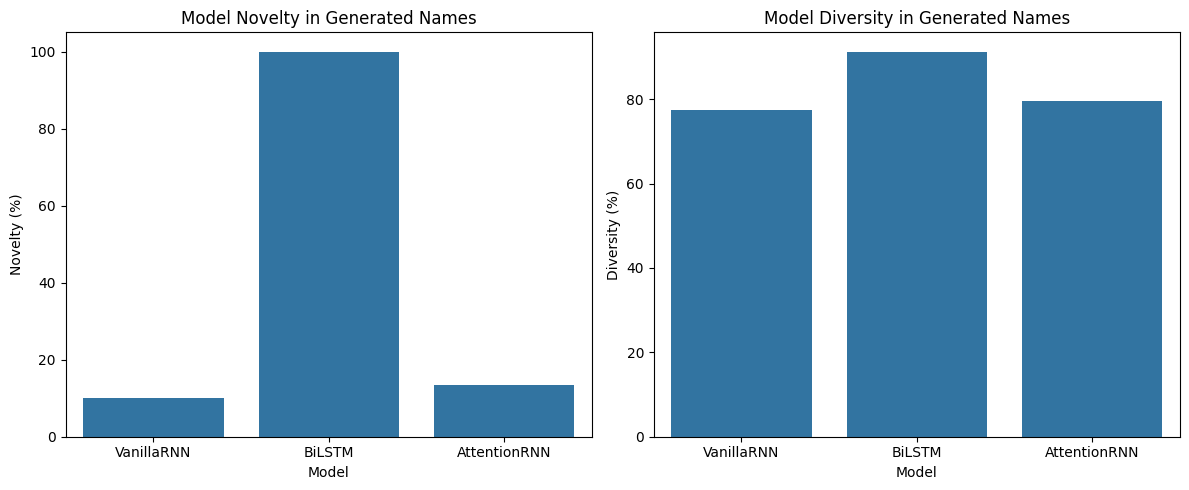

In [38]:
# ─────────────────────────────────────────────
# EVALUATE ALL MODELS
# ─────────────────────────────────────────────
results_list = []

for model_name, model in models.items():
    total, novelty, diversity = evaluate_model(model, model_name=model_name)

    results_list.append({
        "Model": model_name,
        "Total Generated": total,
        "Novelty (%)": novelty,
        "Diversity (%)": diversity
    })
# Convert results to DataFrame
results_df = pd.DataFrame(results_list)

# Display results
print(results_df)


# ─────────────────────────────────────────────
# PLOT RESULTS (NOVELTY & DIVERSITY)
# ─────────────────────────────────────────────
plt.figure(figsize=(12, 5))


# ── Plot 1: Novelty ──────────────────────────
plt.subplot(1, 2, 1)
sns.barplot(x="Model", y="Novelty (%)", data=results_df)
plt.title("Model Novelty in Generated Names")
plt.ylabel("Novelty (%)")


# ── Plot 2: Diversity ────────────────────────
plt.subplot(1, 2, 2)
sns.barplot(x="Model", y="Diversity (%)", data=results_df)
plt.title("Model Diversity in Generated Names")
plt.ylabel("Diversity (%)")


# Show plots
plt.tight_layout()
plt.show()

In [36]:
display(results_df)

,Model,Total Generated,Novelty (%),Diversity (%)
0,VanillaRNN,200,11.0,75.000000
1,BiLSTM,184,100.0,95.652174
2,AttentionRNN,200,13.5,78.500000


In [37]:
vanilla_rnn_params = 222683
# Assuming each parameter is a float32, which is 4 bytes
model_size_bytes = vanilla_rnn_params * 4
model_size_mb = model_size_bytes / (1024 * 1024)

print(f"VanillaRNN has {vanilla_rnn_params:,} parameters.")
print(f"Estimated size of VanillaRNN model: {model_size_mb:.3f} MB")

VanillaRNN has 222,683 parameters.
Estimated size of VanillaRNN model: 0.849 MB
